In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

from xgboost import XGBClassifier

In [51]:
df = pd.read_csv("../data/loan_customers.csv")
df.head()

,customer_id,age,income,loan_amount,tenure,employment_type,credit_score,city,default_flag
0,1,25,25000,50000,12,Contract,580,Delhi,1
1,2,35,60000,200000,24,Salaried,720,Mumbai,0
2,3,40,45000,150000,36,Business,650,Pune,0
3,4,29,30000,80000,12,Contract,590,Delhi,1
4,5,50,80000,300000,48,Salaried,780,Mumbai,0


In [52]:
# define targets and features
target = "default_flag" # update if needed

X = df.drop(columns=["customer_id", "income", target])
y = df[target]

In [53]:
# identify columns types
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [54]:
# processing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [55]:
# train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
# XGBoost Model
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(eval_metric="logloss"))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        13

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



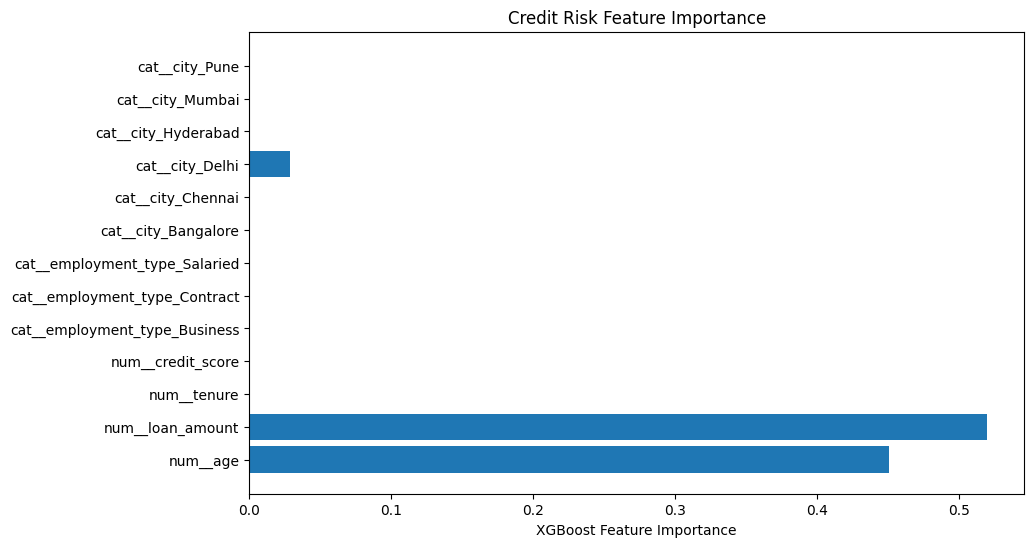

In [65]:

# Get feature importance from the classifier step of pipeline
feature_names = preprocessor.get_feature_names_out()
importances = xgb_model.named_steps['classifier'].feature_importances_
# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("XGBoost Feature Importance")
plt.title("Credit Risk Feature Importance")
plt.show()

In [61]:
# Check the correlation between income and your target variable
correlation = df['income'].corr(df['default_flag'])
print(f"Correlation: {correlation}")

Correlation: -0.7839443643390346


In [64]:
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)
print("Random Forest Report:")
print(classification_report(y_test, rf_model.predict(X_test)))

Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        13

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



<Figure size 800x600 with 0 Axes>

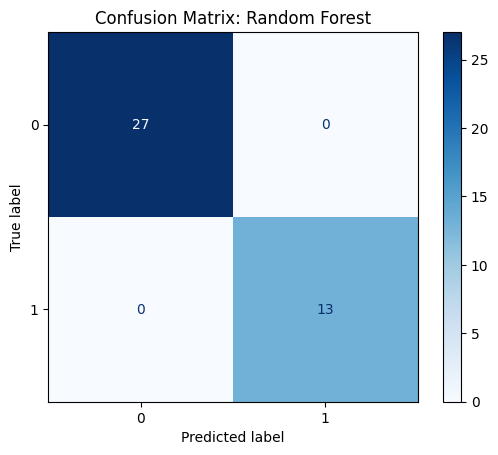

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot for the Random Forest model
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.show()

In [67]:
# logistic regression
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.93      1.00      0.96        13

    accuracy                           0.97        40
   macro avg       0.96      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40

